## Shorts EDA + Data Cleaning + Feature Engineering

### Overview
This notebook covers the full pipeline from raw data to a clean, 
model-ready dataset for makeup YouTube Shorts.

### Steps Covered

**1. Data Loading & Initial Inspection**
- Loaded raw CSV with 2,224 scraped YouTube Shorts
- Final clean dataset: 1,983 videos after filtering incomplete years
- Inspected dtypes, shape, nulls, and basic statistics

**2. Data Cleaning**
- Fixed dtypes (datetime, int32, float32, category)
- Removed incomplete years (2018, 2020, 2021, 2026) — keeping 2022–2025
- Handled integer overflow in total_channel_views (kept as int64)

**3. Feature Engineering**
- Log transformed skewed columns: views, likes, comments, subscriber_count, 
  total_channel_views, total_videos, view_velocity
- Extracted time features: year, quarter, month, day_of_week, hour, hour_bucket
- Created content_type from title keyword classification (15 categories)
- Created subscriber_tier using industry-standard influencer tiers
- Created duration_bucket (0-15s, 16-30s, 31-45s, 46-60s)
- Flagged viral videos using IQR method on views (is_viral)

**4. EDA**
- Distributions of all numerical, categorical, and boolean features
- Engagement rate analysis by time, content type, subscriber tier, and video length
- Correlation heatmap
- Outlier analysis via boxplots

**5. Output**
- Saved clean modeling-ready dataset: `data/makeup_shorts_clean.csv`
- Shape: (1,983 × 25)

In [ ]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
shorts_raw_df = pd.read_csv("data/makeup_shorts_raw.csv")

In [ ]:
shorts_raw_df.head(10)

In [4]:
shorts_raw_df.dtypes

video_id                   str
channel_id                 str
search_query               str
title                      str
description                str
tags                       str
published_at               str
duration_seconds         int64
views                    int64
likes                    int64
comments                 int64
engagement_rate        float64
like_rate              float64
comment_rate           float64
days_since_upload        int64
view_velocity          float64
subscriber_count         int64
total_channel_views      int64
total_videos             int64
url                        str
dtype: object

In [5]:
shorts_raw_df['published_at'] = pd.to_datetime(shorts_raw_df['published_at'])

shorts_raw_df['duration_seconds'] = shorts_raw_df['duration_seconds'].astype('int32')
shorts_raw_df['views'] = shorts_raw_df['views'].astype('int64')
shorts_raw_df['likes'] = shorts_raw_df['likes'].astype('int64')
shorts_raw_df['comments'] = shorts_raw_df['comments'].astype('int32')
shorts_raw_df['days_since_upload'] = shorts_raw_df['days_since_upload'].astype('int32')
shorts_raw_df['subscriber_count'] = shorts_raw_df['subscriber_count'].astype('int64')
shorts_raw_df['total_channel_views'] = shorts_raw_df['total_channel_views'].astype('int64')
shorts_raw_df['total_videos'] = shorts_raw_df['total_videos'].astype('int64')

shorts_raw_df['engagement_rate'] = shorts_raw_df['engagement_rate'].astype('float32')
shorts_raw_df['like_rate'] = shorts_raw_df['like_rate'].astype('float32')
shorts_raw_df['comment_rate'] = shorts_raw_df['comment_rate'].astype('float32')
shorts_raw_df['view_velocity'] = shorts_raw_df['view_velocity'].astype('float32')

shorts_raw_df['search_query'] = shorts_raw_df['search_query'].astype('category')

In [6]:
shorts_raw_df.dtypes

video_id                               str
channel_id                             str
search_query                      category
title                                  str
description                            str
tags                                   str
published_at           datetime64[us, UTC]
duration_seconds                     int32
views                                int64
likes                                int64
comments                             int32
engagement_rate                    float32
like_rate                          float32
comment_rate                       float32
days_since_upload                    int32
view_velocity                      float32
subscriber_count                     int64
total_channel_views                  int64
total_videos                         int64
url                                    str
dtype: object

In [ ]:
shorts_raw_df.head(10)

In [9]:
numeric_cols = ["duration_seconds","views","likes","comments","days_since_upload","subscriber_count","total_channel_views","total_videos"]

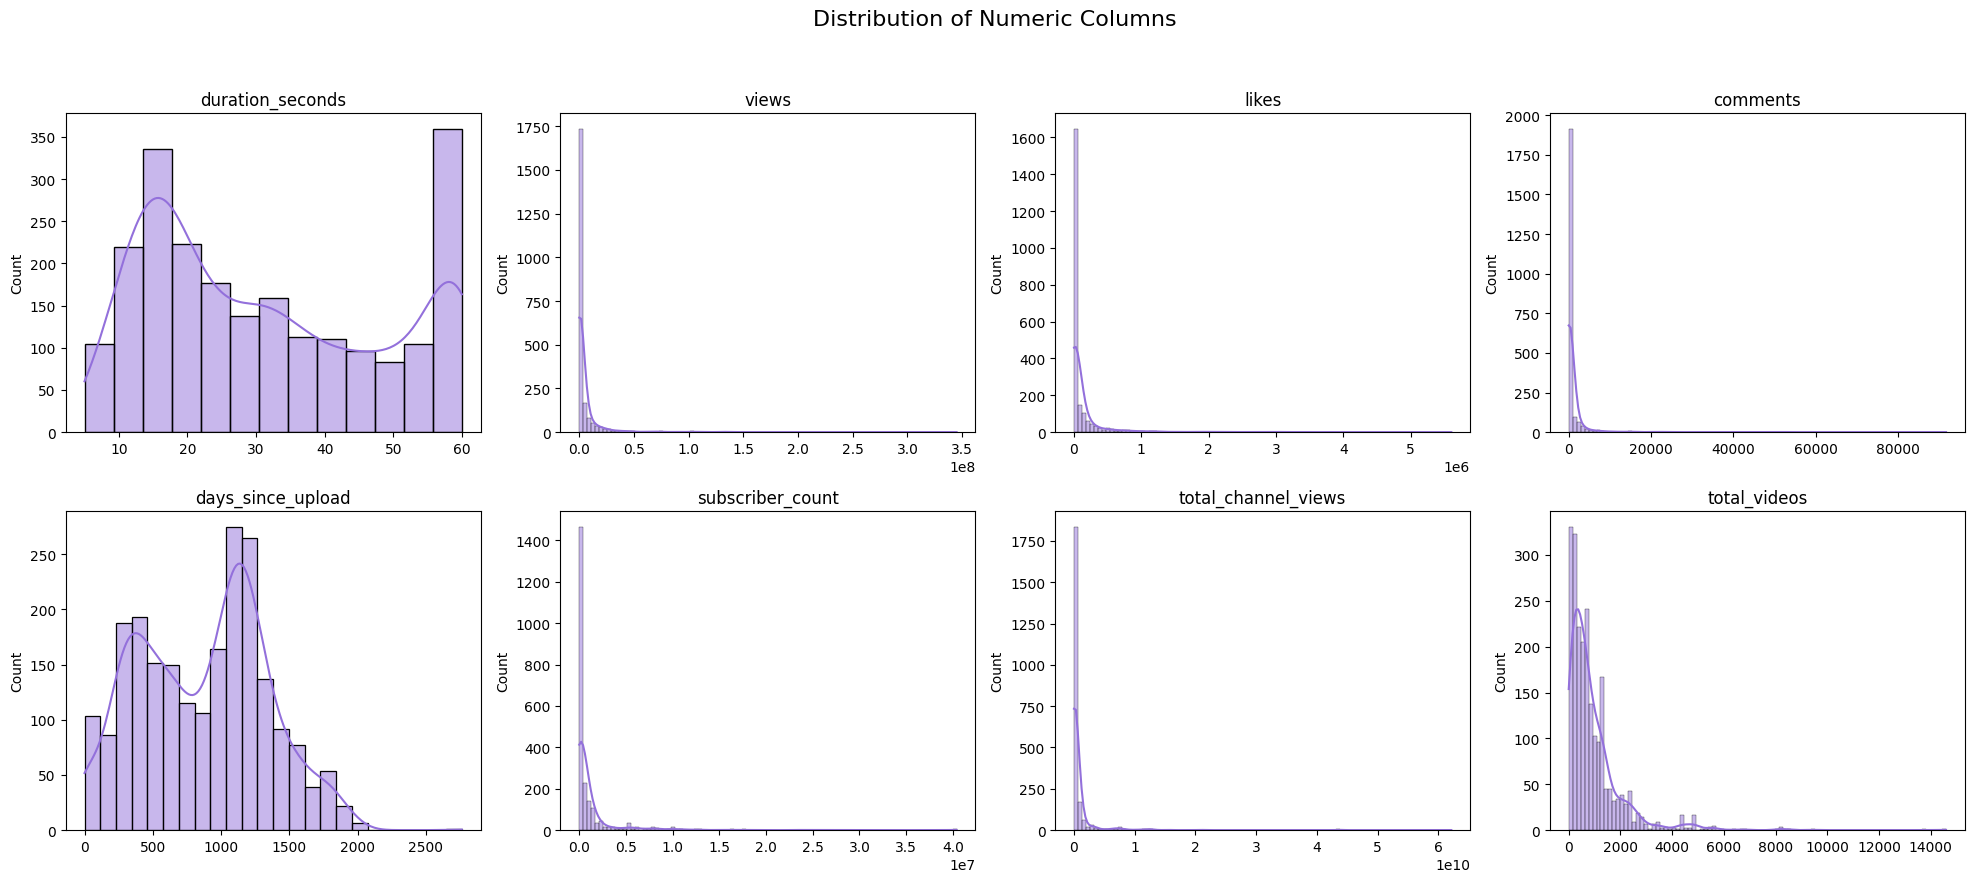

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=shorts_raw_df, x=col, ax=axes[i], kde=True, color='mediumpurple')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numeric Columns', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
skewed_cols = ['views', 'likes', 'comments', 'subscriber_count', 'total_channel_views']

for col in skewed_cols:
    shorts_raw_df[f'log_{col}'] = np.log1p(shorts_raw_df[col])

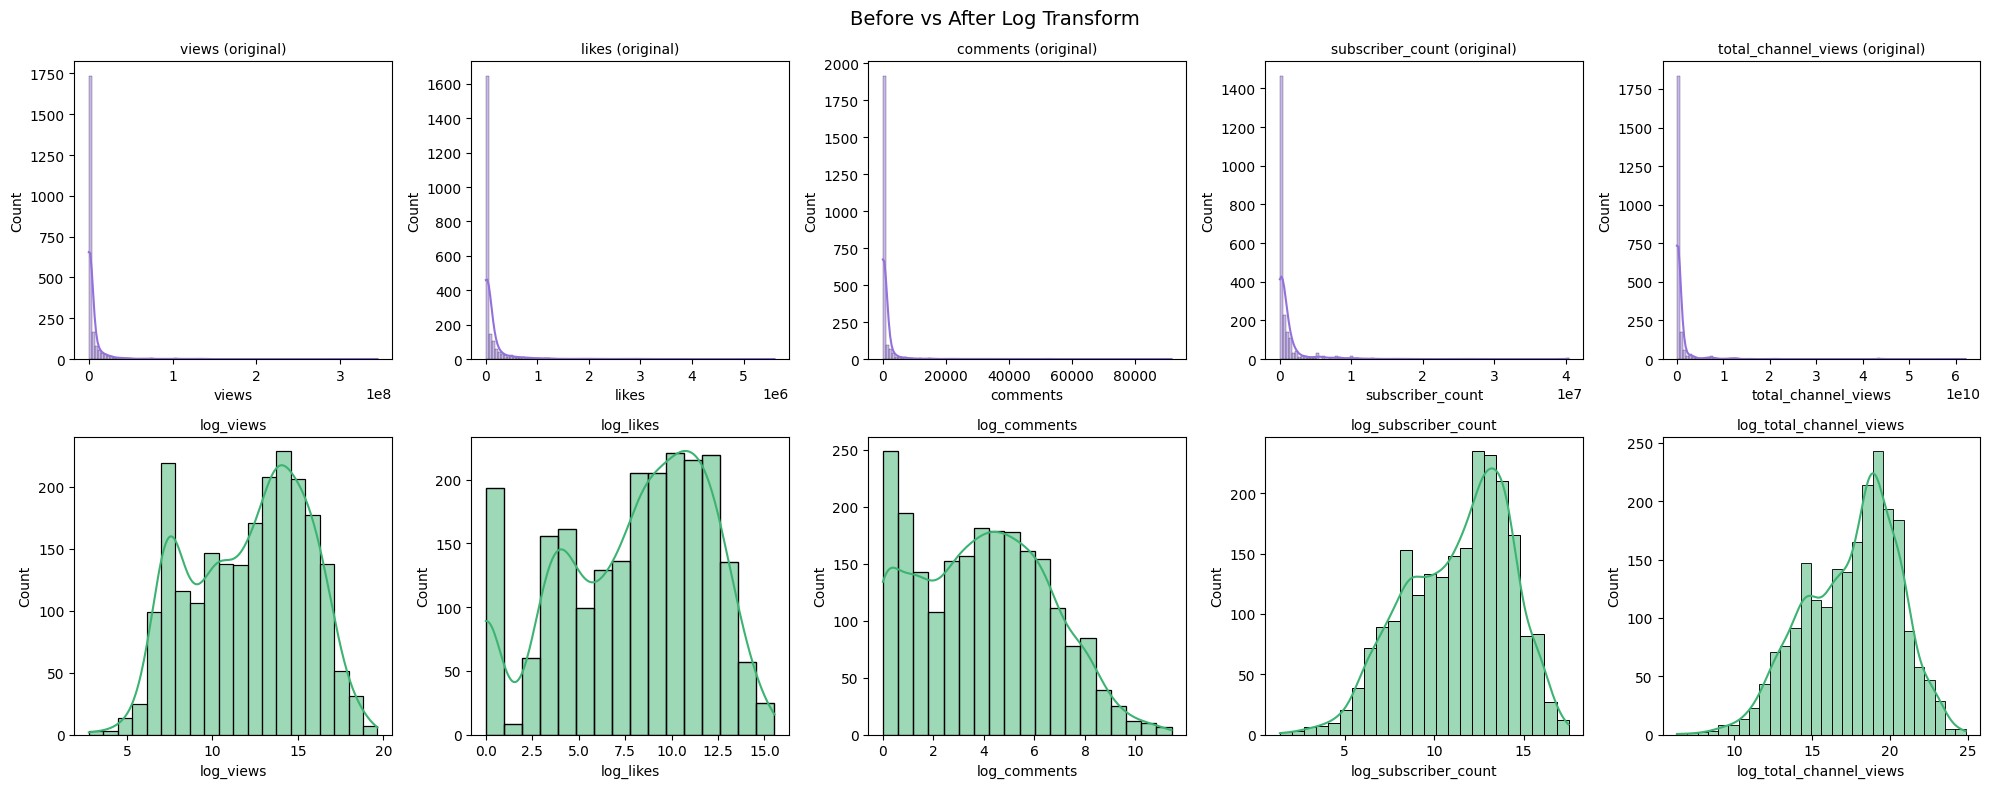

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))

for i, col in enumerate(skewed_cols):
    # original
    sns.histplot(data=shorts_raw_df, x=col, ax=axes[0][i], kde=True, color='mediumpurple')
    axes[0][i].set_title(f'{col} (original)', fontsize=10)

    # log transformed
    sns.histplot(data=shorts_raw_df, x=f'log_{col}', ax=axes[1][i], kde=True, color='mediumseagreen')
    axes[1][i].set_title(f'log_{col}', fontsize=10)

plt.suptitle('Before vs After Log Transform', fontsize=14)
plt.tight_layout()
plt.show()

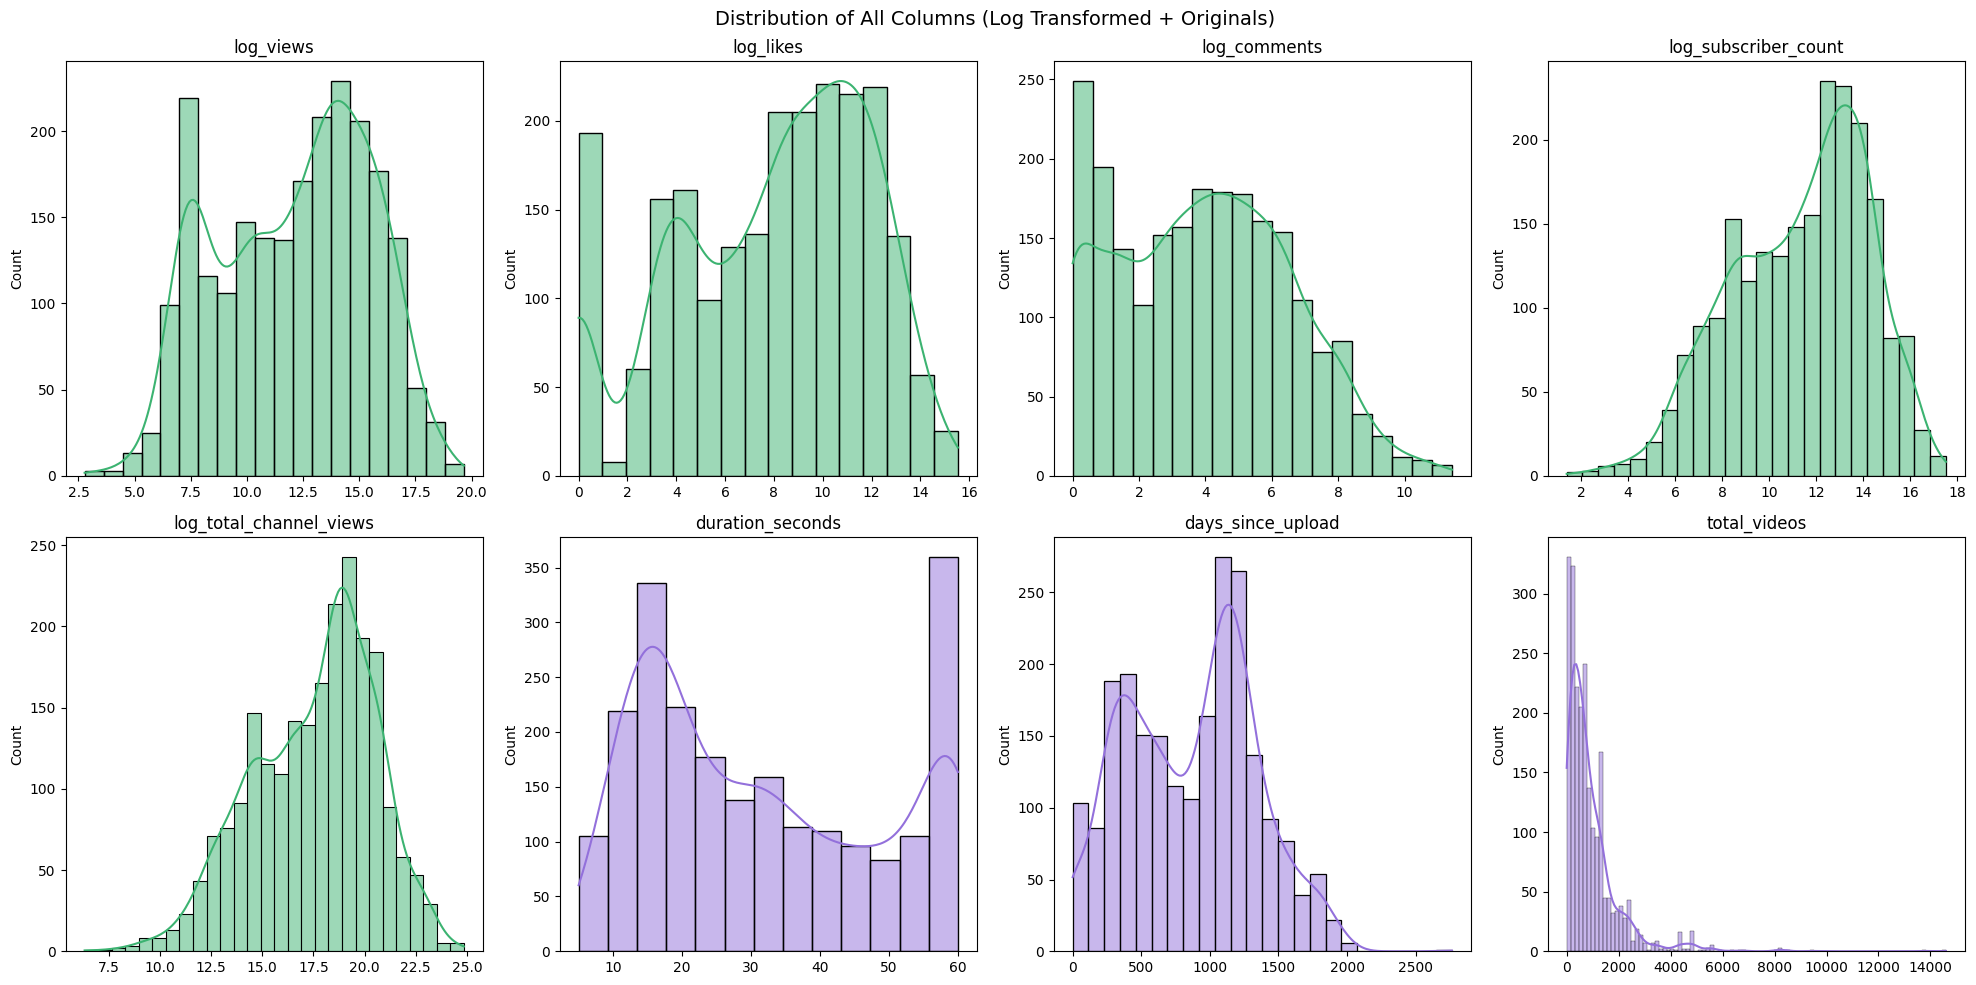

In [13]:
log_cols = ['log_views', 'log_likes', 'log_comments', 'log_subscriber_count', 'log_total_channel_views']
original_cols = ['duration_seconds', 'days_since_upload', 'total_videos']

all_cols = log_cols + original_cols

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(all_cols):
    color = 'mediumseagreen' if col.startswith('log_') else 'mediumpurple'
    sns.histplot(data=shorts_raw_df, x=col, ax=axes[i], kde=True, color=color)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')

for j in range(len(all_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Columns (Log Transformed + Originals)', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
shorts_raw_df['log_total_videos'] = np.log1p(shorts_raw_df['total_videos'])

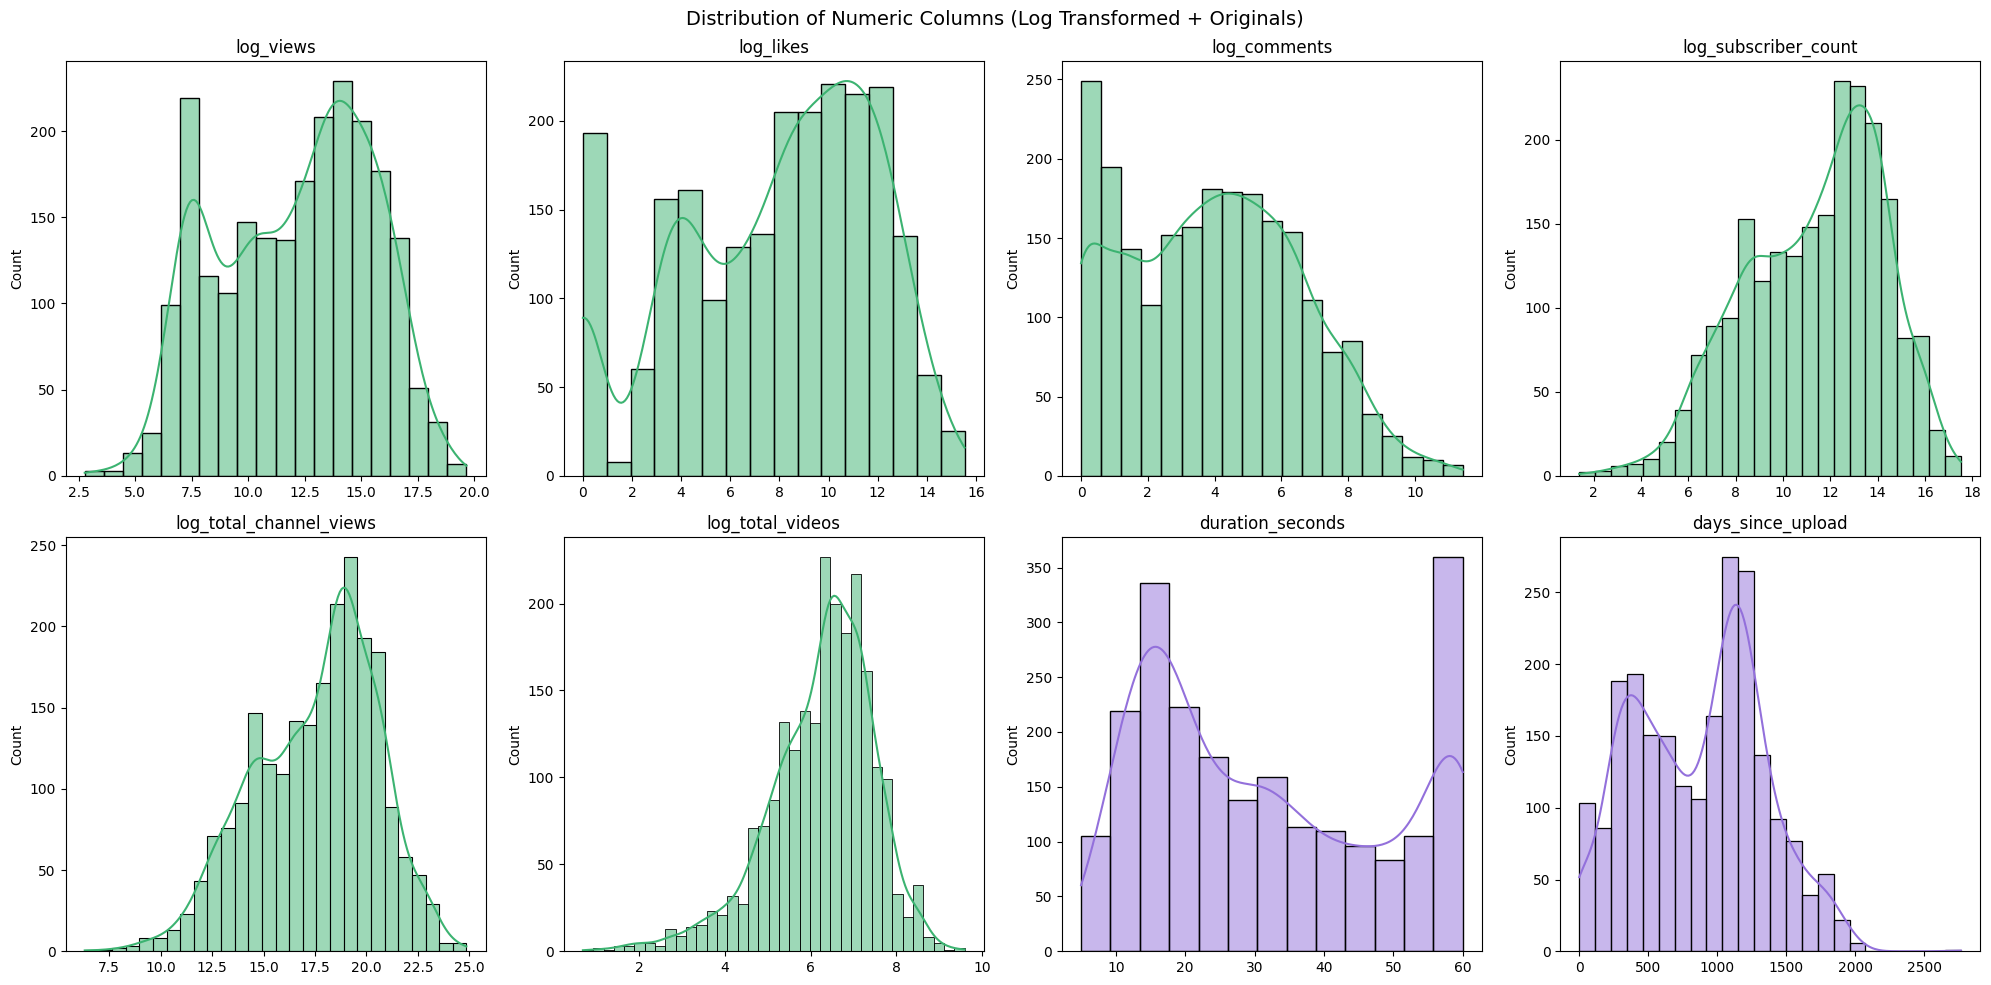

In [15]:
log_cols = ['log_views', 'log_likes', 'log_comments', 'log_subscriber_count',
            'log_total_channel_views', 'log_total_videos']
original_cols = ['duration_seconds', 'days_since_upload']

all_cols = log_cols + original_cols

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(all_cols):
    color = 'mediumseagreen' if col.startswith('log_') else 'mediumpurple'
    sns.histplot(data=shorts_raw_df, x=col, ax=axes[i], kde=True, color=color)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')

for j in range(len(all_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numeric Columns (Log Transformed + Originals)', fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
shorts_raw_df['hour'] = shorts_raw_df['published_at'].dt.hour
shorts_raw_df['day_of_week'] = shorts_raw_df['published_at'].dt.day_name()
shorts_raw_df['month'] = shorts_raw_df['published_at'].dt.month_name()
shorts_raw_df['quarter'] = shorts_raw_df['published_at'].dt.quarter
shorts_raw_df['year'] = shorts_raw_df['published_at'].dt.year

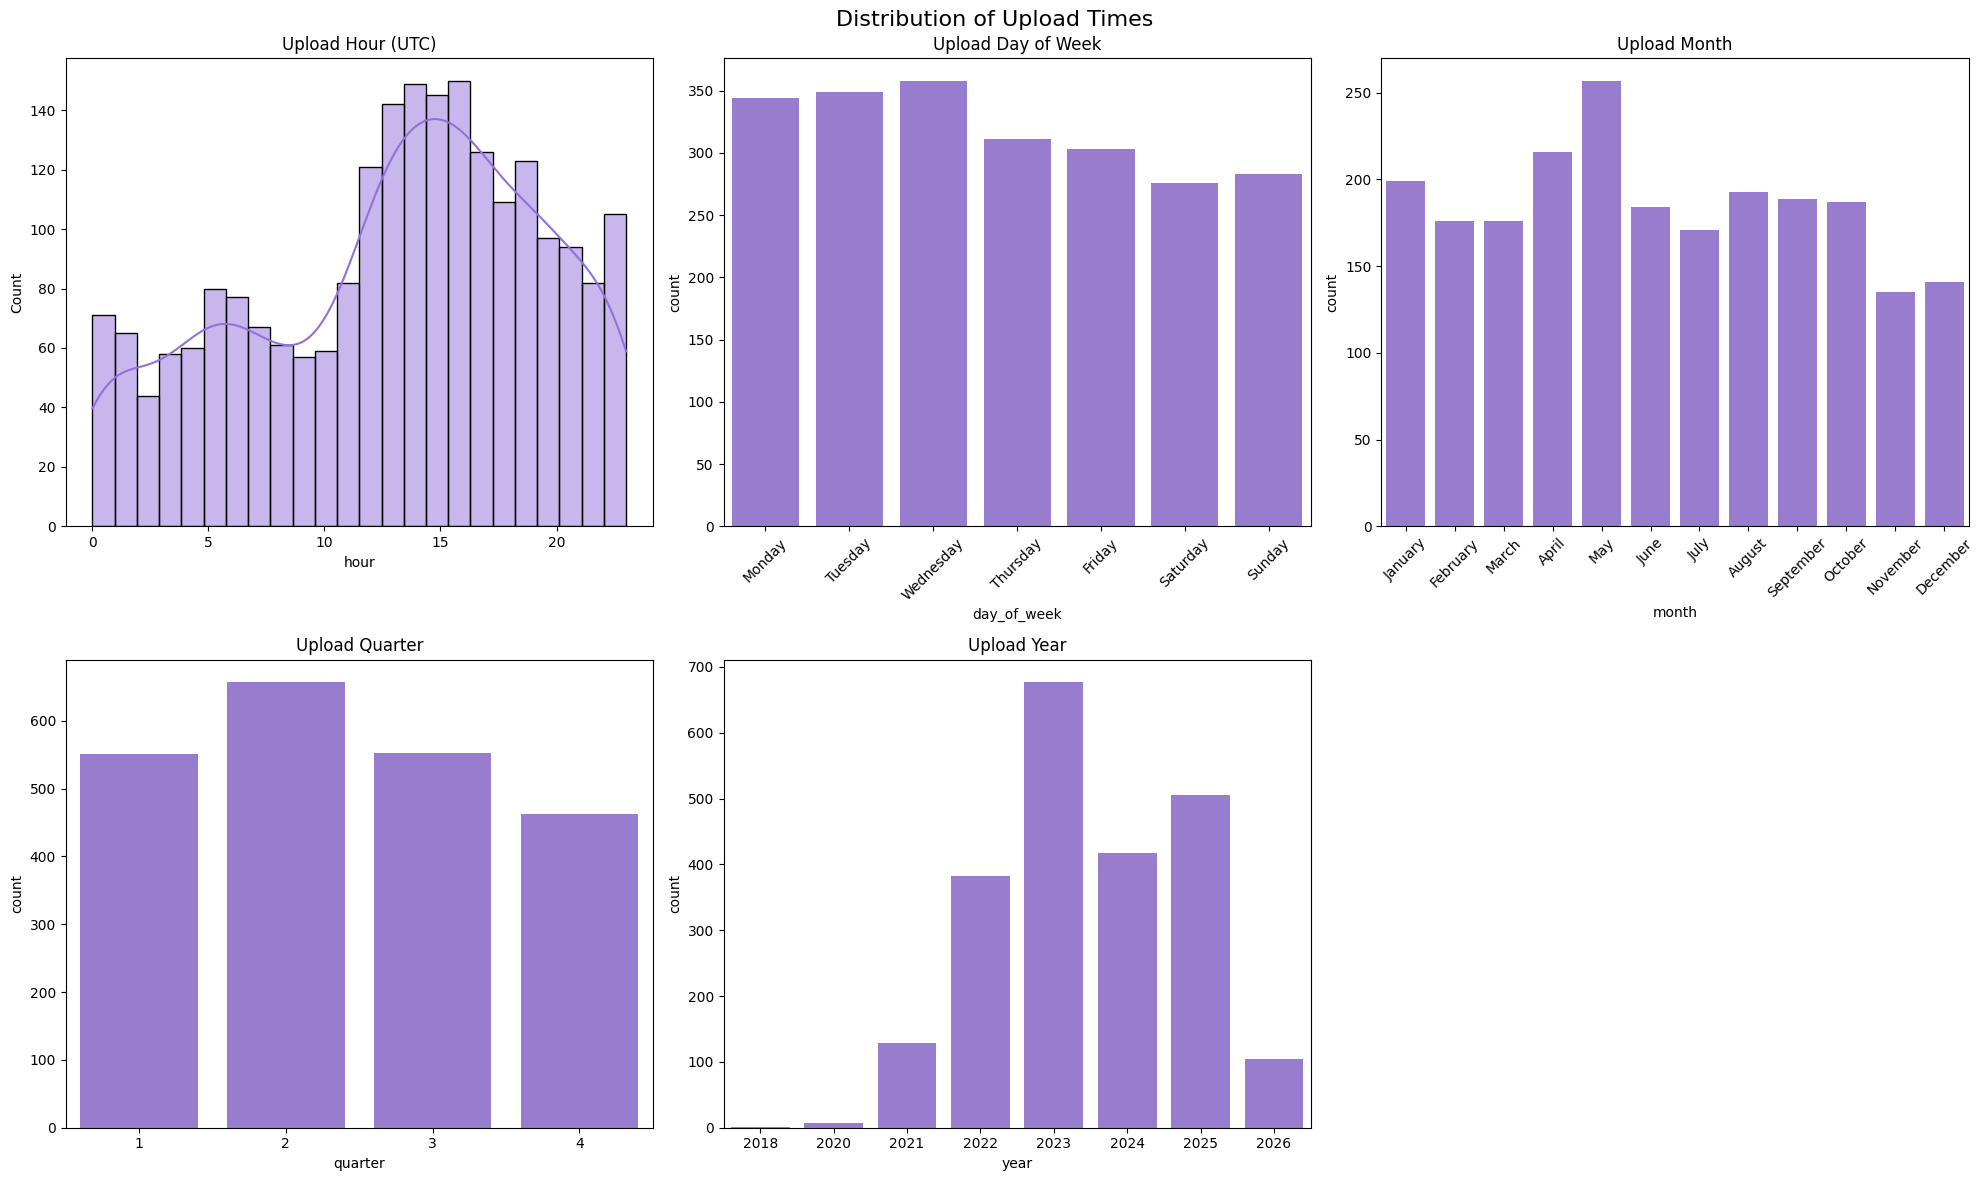

In [ ]:
time_cols = ['hour', 'day_of_week', 'month', 'quarter', 'year']

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
axes = axes.flatten()

# hour
sns.histplot(data=shorts_raw_df, x='hour', ax=axes[0], bins=24, color='mediumpurple', kde=True)
axes[0].set_title('Upload Hour (UTC)')

# day of week
sns.countplot(data=shorts_raw_df, x='day_of_week', ax=axes[1], order=day_order, color='mediumpurple')
axes[1].set_title('Upload Day of Week')
axes[1].tick_params(axis='x', rotation=45)

# month
sns.countplot(data=shorts_raw_df, x='month', ax=axes[2], order=month_order, color='mediumpurple')
axes[2].set_title('Upload Month')
axes[2].tick_params(axis='x', rotation=45)

# quarter
sns.countplot(data=shorts_raw_df, x='quarter', ax=axes[3], color='mediumpurple')
axes[3].set_title('Upload Quarter')

# year
sns.countplot(data=shorts_raw_df, x='year', ax=axes[4], color='mediumpurple')
axes[4].set_title('Upload Year')

axes[5].set_visible(False)

plt.suptitle('Distribution of Upload Times', fontsize=16)
plt.tight_layout()
plt.show()

In [20]:
shorts_raw_df = shorts_raw_df[~shorts_raw_df['year'].isin([2018, 2020, 2021, 2026])]

In [21]:
tags_exploded = (
    shorts_raw_df['tags']
    .dropna()
    .str.split('|')
    .explode()
    .str.lower()
    .str.strip()
)

top_tags = tags_exploded.value_counts().head(30)
print(top_tags)

tags
makeup                   312
shorts                   211
makeup tutorial          188
beauty                   116
makeup shorts             81
youtube shorts            80
makeup hacks              68
makeup tips               59
drugstore makeup          57
viral                     54
grwm                      46
tiktok                    46
#shorts                   46
makeup for beginners      45
tutorial                  42
makeup transformation     42
how to                    40
easy makeup               39
makeup hack               39
lipstick                  38
dupes                     38
viral shorts              37
best drugstore makeup     37
affordable makeup         37
concealer hack            37
makeup artist             35
trending                  35
beauty hacks              35
#makeup                   35
everyday makeup           34
Name: count, dtype: int64


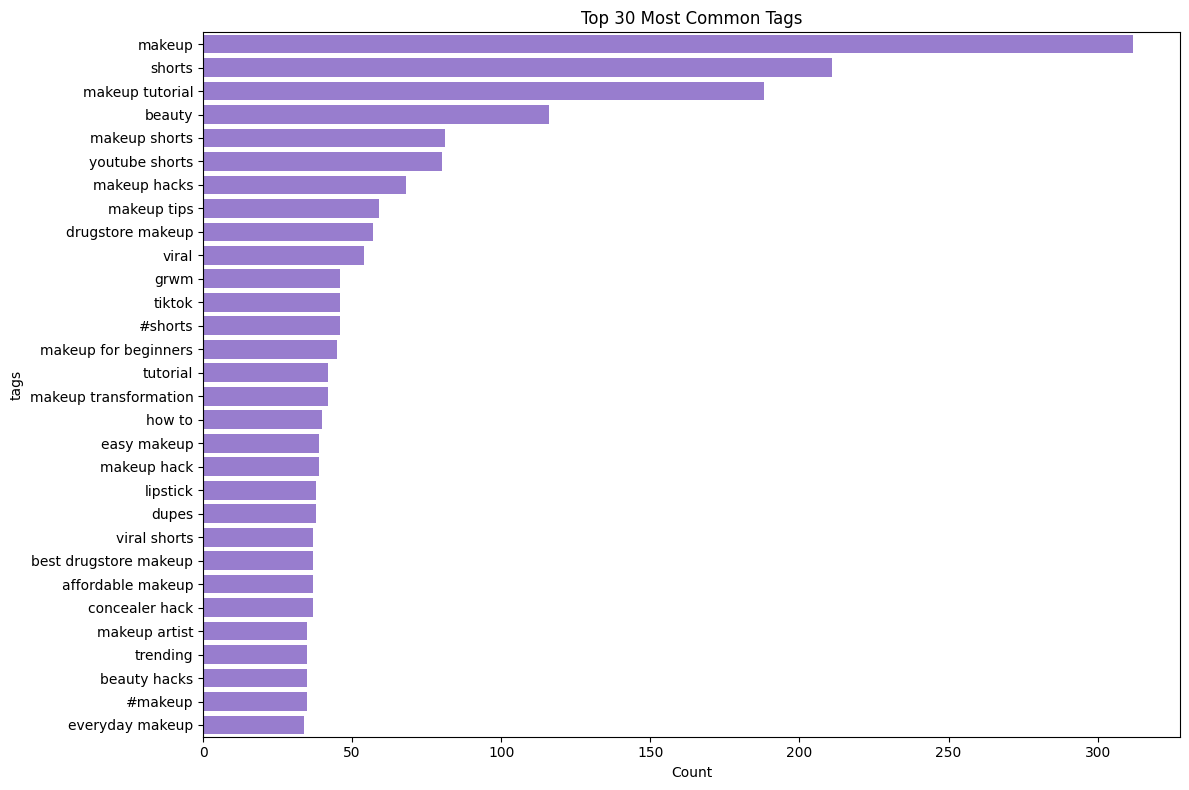

In [22]:
# plot top tags
plt.figure(figsize=(12, 8))
sns.barplot(x=top_tags.values, y=top_tags.index, color='mediumpurple')
plt.title('Top 30 Most Common Tags')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

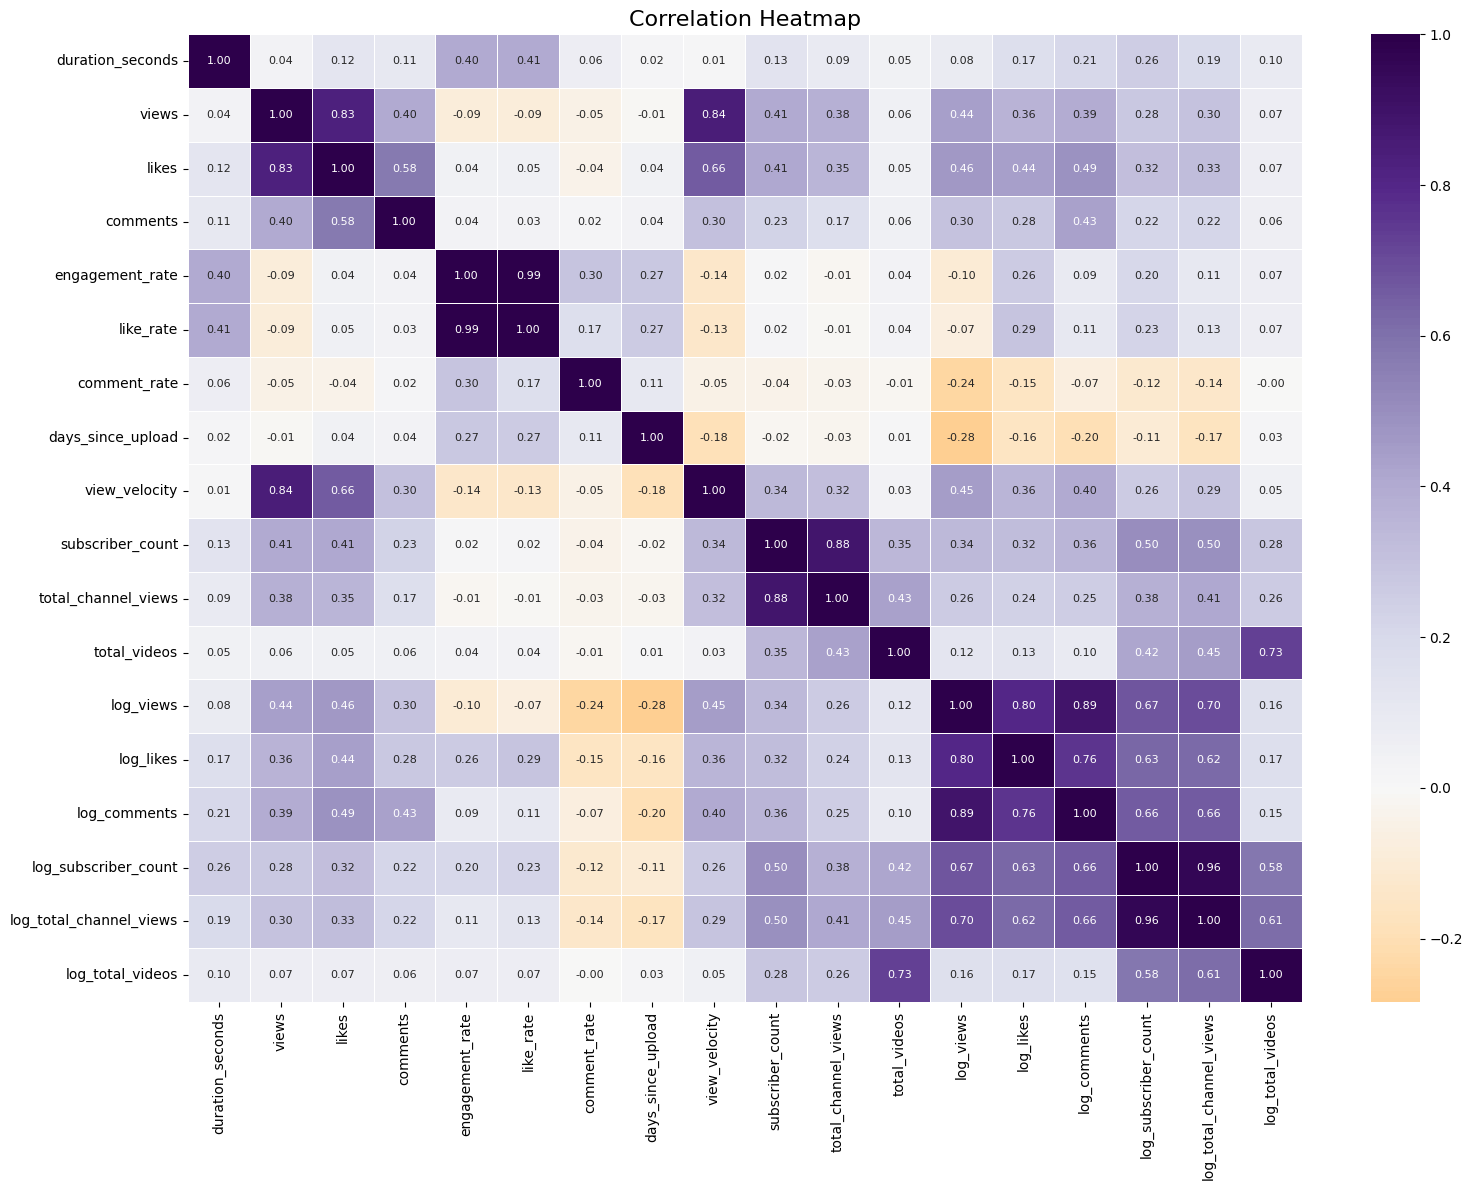

In [23]:
corr_cols = ['duration_seconds', 'views', 'likes', 'comments',
             'engagement_rate', 'like_rate', 'comment_rate',
             'days_since_upload', 'view_velocity', 'subscriber_count',
             'total_channel_views', 'total_videos',
             'log_views', 'log_likes', 'log_comments',
             'log_subscriber_count', 'log_total_channel_views', 'log_total_videos']

corr_matrix = shorts_raw_df[corr_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='PuOr',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

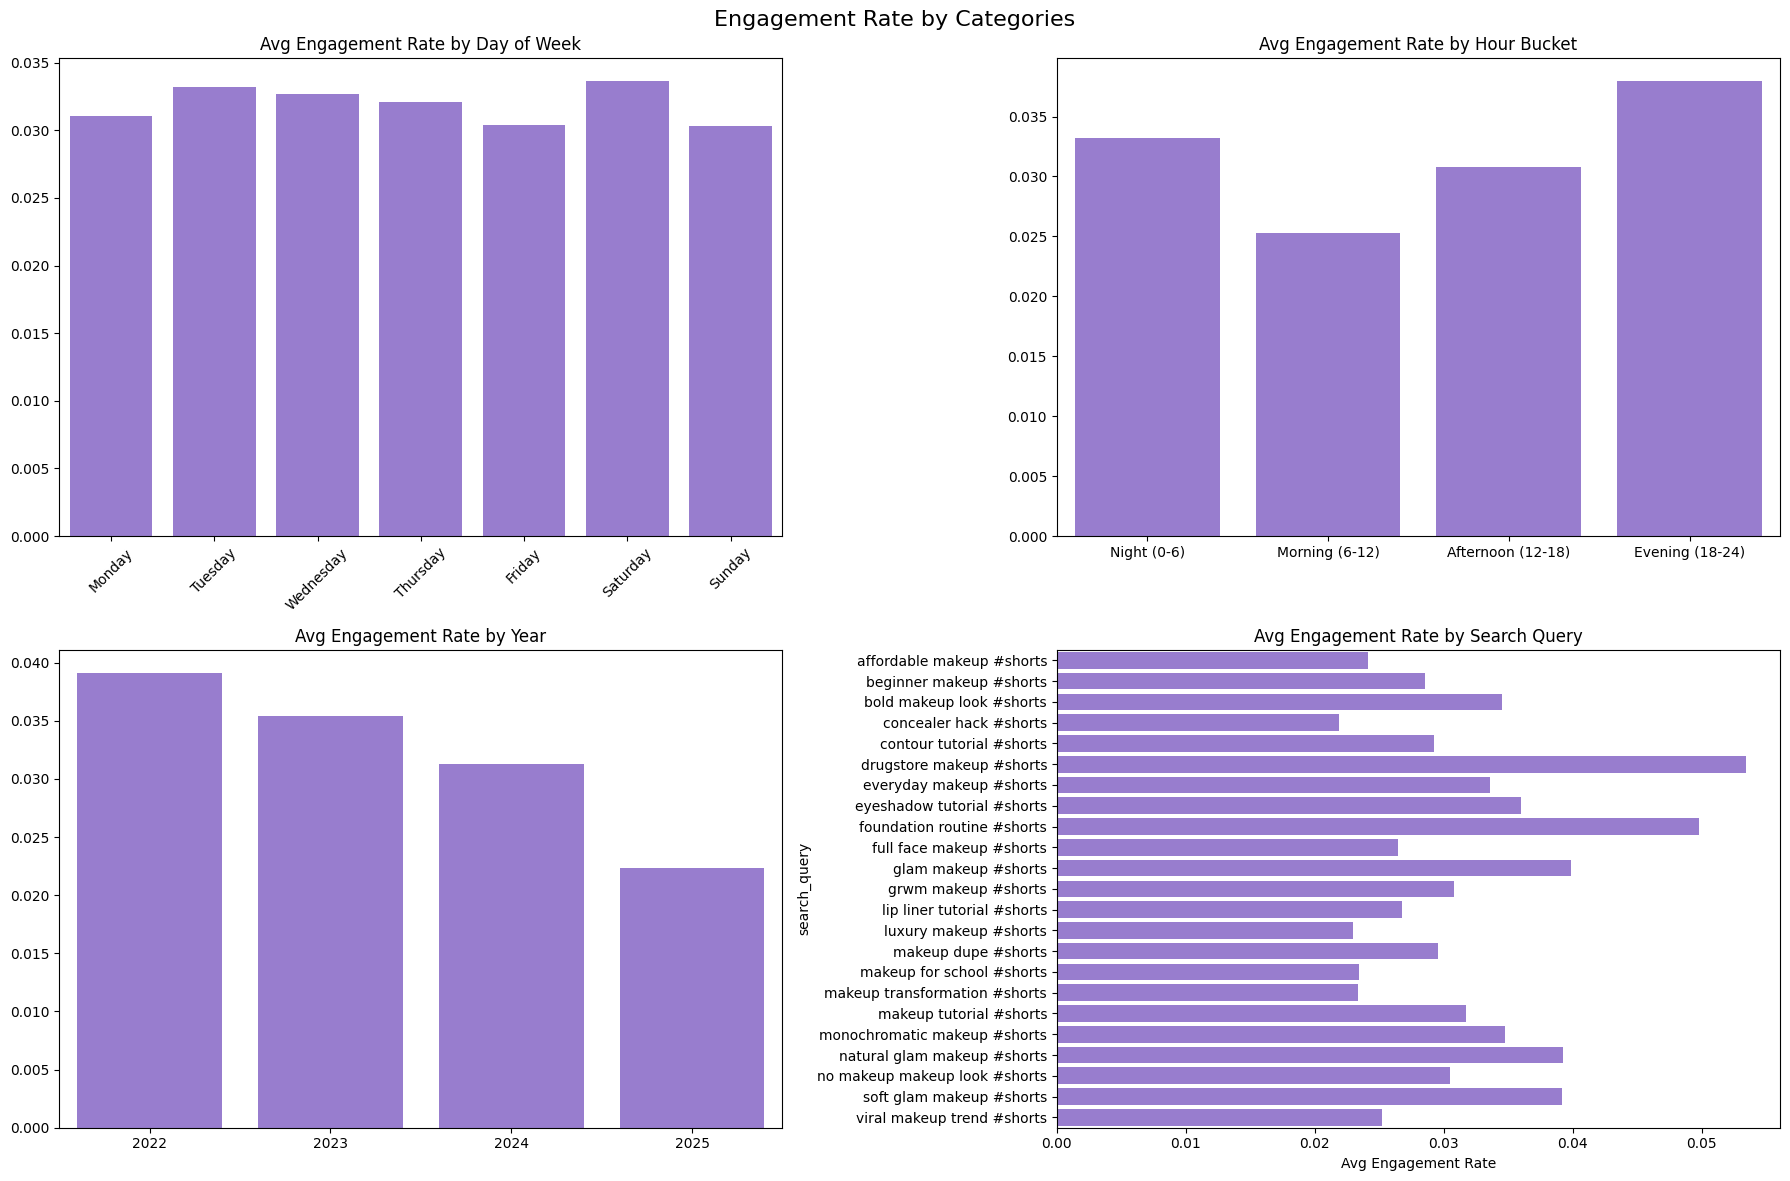

In [24]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_by_day = shorts_raw_df.groupby('day_of_week')['engagement_rate'].mean().reindex(day_order)
sns.barplot(x=avg_by_day.index, y=avg_by_day.values, ax=axes[0][0], color='mediumpurple')
axes[0][0].set_title('Avg Engagement Rate by Day of Week')
axes[0][0].set_xlabel('')
axes[0][0].tick_params(axis='x', rotation=45)

# hour buckets
shorts_raw_df['hour_bucket'] = pd.cut(shorts_raw_df['hour'],
                                       bins=[0, 6, 12, 18, 24],
                                       labels=['Night (0-6)', 'Morning (6-12)',
                                               'Afternoon (12-18)', 'Evening (18-24)'])
avg_by_hour = shorts_raw_df.groupby('hour_bucket', observed=True)['engagement_rate'].mean()
sns.barplot(x=avg_by_hour.index, y=avg_by_hour.values, ax=axes[0][1], color='mediumpurple')
axes[0][1].set_title('Avg Engagement Rate by Hour Bucket')
axes[0][1].set_xlabel('')

# by year
avg_by_year = shorts_raw_df.groupby('year')['engagement_rate'].mean()
sns.barplot(x=avg_by_year.index, y=avg_by_year.values, ax=axes[1][0], color='mediumpurple')
axes[1][0].set_title('Avg Engagement Rate by Year')
axes[1][0].set_xlabel('')

# by search query
avg_by_query = shorts_raw_df.groupby('search_query')['engagement_rate'].mean().sort_values(ascending=False)
sns.barplot(x=avg_by_query.values, y=avg_by_query.index, ax=axes[1][1], color='mediumpurple')
axes[1][1].set_title('Avg Engagement Rate by Search Query')
axes[1][1].set_xlabel('Avg Engagement Rate')

plt.suptitle('Engagement Rate by Categories', fontsize=16)
plt.tight_layout()
plt.show()

In [36]:
def classify_content_type(title):
    title = title.lower()
    if any(word in title for word in ['grwm', 'get ready with me', 'get ready with us', 'grwu']):
        return 'GRWM'
    elif any(word in title for word in ['transformation', 'before and after', 'unrecognizable', 'makeover']):
        return 'Transformation'
    elif any(word in title for word in ['dupe', 'drugstore', 'affordable', 'cheap']):
        return 'Dupe/Affordable'
    elif any(word in title for word in ['beginner', 'easy', 'simple', 'basic']):
        return 'Beginner'
    elif any(word in title for word in ['glam', 'bold', 'full face', 'full glam']):
        return 'Glam'
    elif any(word in title for word in ['natural', 'no makeup', 'clean girl', 'minimal', 'no-makeup']):
        return 'Natural'
    elif any(word in title for word in ['tutorial', 'how to', 'step by step', 'tut']):
        return 'Tutorial'
    elif any(word in title for word in ['kpop', 'k-pop', 'korean', 'idol', 'kbeauty', 'k-beauty']):
        return 'K-Beauty/KPop'
    elif any(word in title for word in ['sephora', 'ulta', 'haul', 'new in', 'unboxing']):
        return 'Haul/Shopping'
    elif any(word in title for word in ['school', 'everyday', 'daily', 'work', 'office']):
        return 'Everyday/School'
    elif any(word in title for word in ['power of makeup', 'transition', 'ranking', 'satisfying']):
        return 'Transition/Ranking'
    elif any(word in title for word in ['hack', 'hacks', 'tip', 'trick', 'method', 'technique']):
        return 'Hack/Tip'
    elif any(word in title for word in ['routine', 'everyday routine', 'morning routine', 'glowy']):
        return 'Routine'
    elif any(word in title for word in ['acne','texture','red','redness','pimple','pimples','hormone','hormonal','pores', 'hyperpigmentation', 'dark spots',
                                     'blemish', 'foundation coverage', 'flawless skin']):
        return 'Skin/Coverage'
    else:
        return 'Other'

shorts_raw_df['content_type'] = shorts_raw_df['title'].apply(classify_content_type)
print(shorts_raw_df['content_type'].value_counts())

content_type
Other                 390
Tutorial              286
Dupe/Affordable       250
Glam                  217
Hack/Tip              185
Beginner              154
GRWM                  152
Transformation         97
Natural                68
Routine                47
Everyday/School        43
K-Beauty/KPop          33
Transition/Ranking     30
Haul/Shopping          20
Skin/Coverage          11
Name: count, dtype: int64


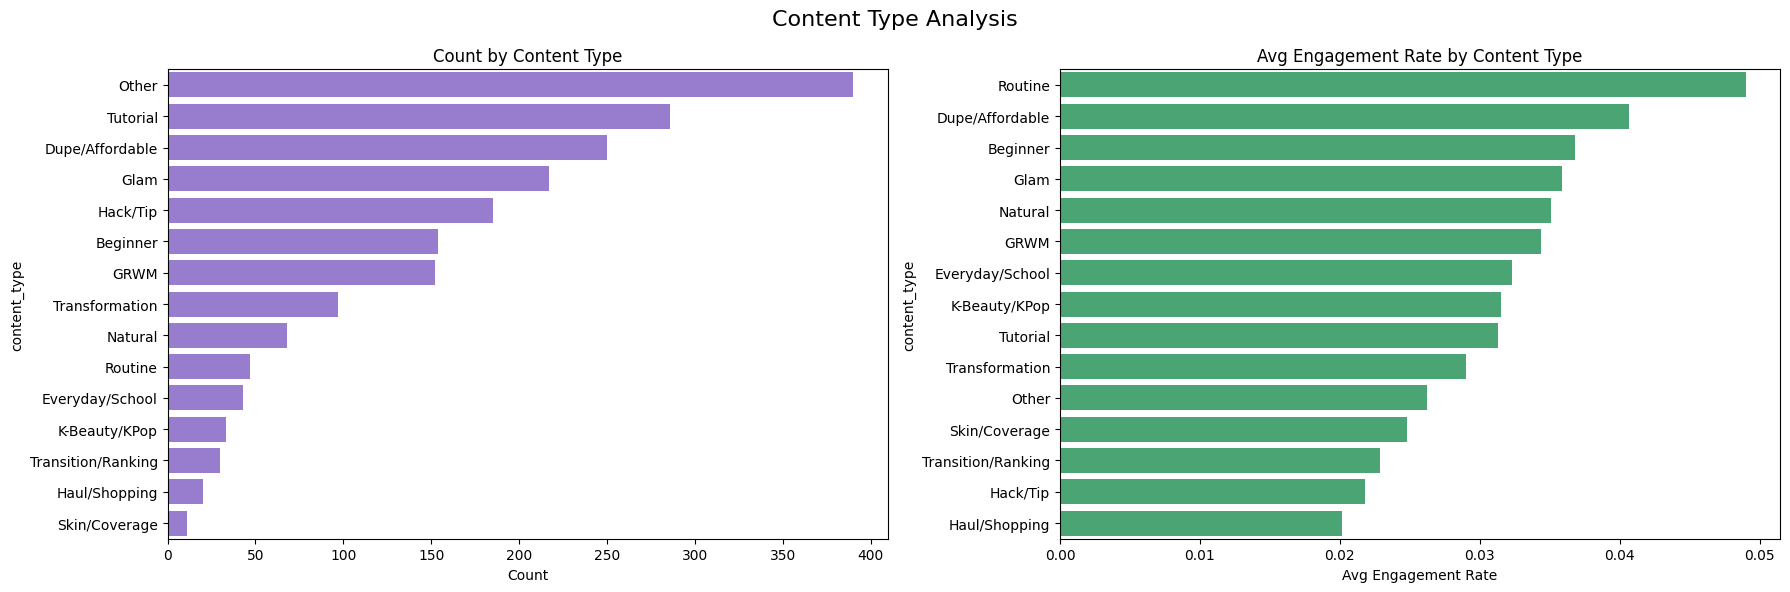

In [38]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# count of each content type
content_counts = shorts_raw_df['content_type'].value_counts()
sns.barplot(x=content_counts.values, y=content_counts.index, ax=axes[0], color='mediumpurple')
axes[0].set_title('Count by Content Type')
axes[0].set_xlabel('Count')

# avg engagement rate by content type
avg_by_content = shorts_raw_df.groupby('content_type')['engagement_rate'].mean().sort_values(ascending=False)
sns.barplot(x=avg_by_content.values, y=avg_by_content.index, ax=axes[1], color='mediumseagreen')
axes[1].set_title('Avg Engagement Rate by Content Type')
axes[1].set_xlabel('Avg Engagement Rate')

plt.suptitle('Content Type Analysis', fontsize=16)
plt.tight_layout()
plt.show()

In [39]:
def assign_tier(sub_count):
    if sub_count < 1_000:
        return 'Unknown (<1K)'
    elif sub_count < 5_000:
        return 'Nano (1K-5K)'
    elif sub_count < 50_000:
        return 'Micro (5K-50K)'
    elif sub_count < 300_000:
        return 'Mid-Tier (50K-300K)'
    elif sub_count < 1_000_000:
        return 'Macro (300K-1M)'
    else:
        return 'Mega (1M+)'

shorts_raw_df['subscriber_tier'] = shorts_raw_df['subscriber_count'].apply(assign_tier)

tier_order = ['Unknown (<1K)', 'Nano (1K-5K)', 'Micro (5K-50K)',
              'Mid-Tier (50K-300K)', 'Macro (300K-1M)', 'Mega (1M+)']

print(shorts_raw_df['subscriber_tier'].value_counts())

subscriber_tier
Mega (1M+)             457
Mid-Tier (50K-300K)    405
Micro (5K-50K)         400
Macro (300K-1M)        359
Nano (1K-5K)           214
Unknown (<1K)          148
Name: count, dtype: int64


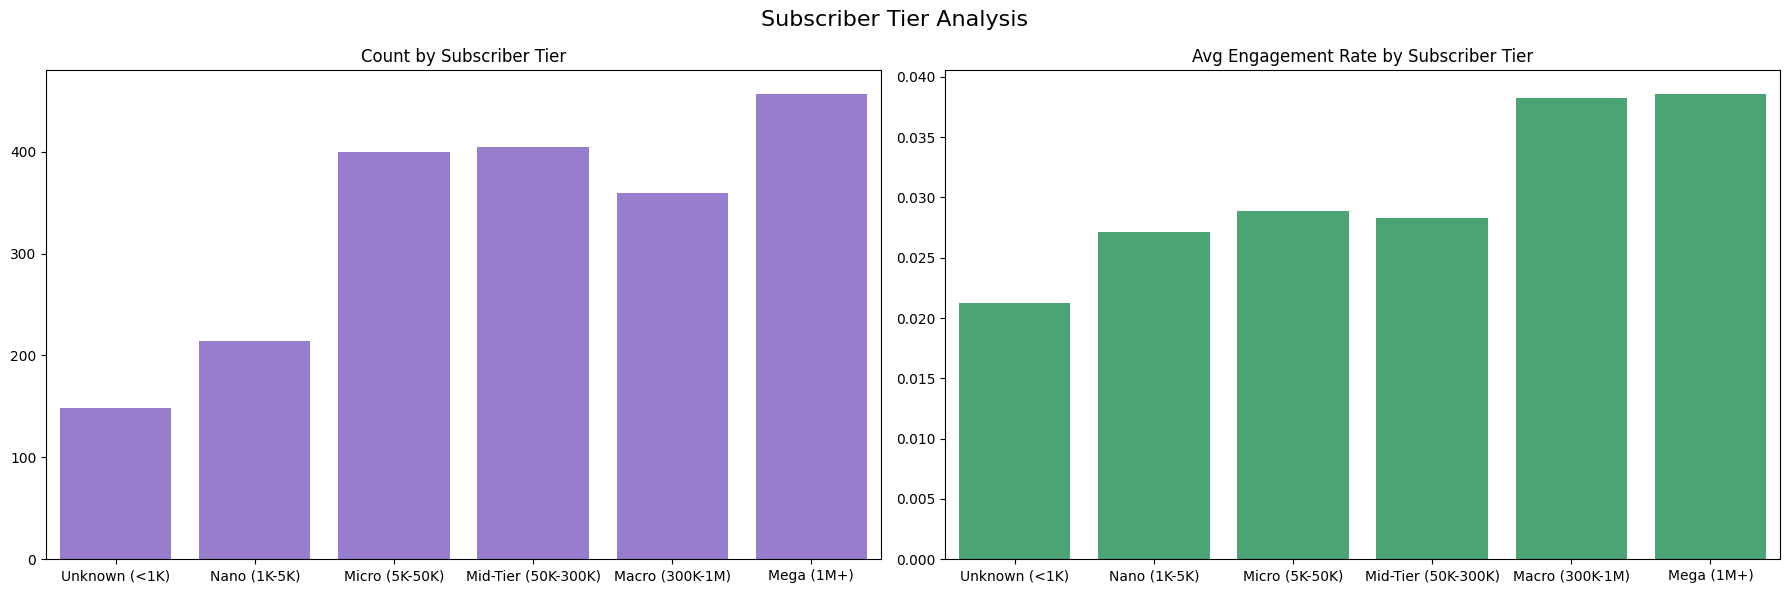

In [40]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# count per tier
tier_counts = shorts_raw_df['subscriber_tier'].value_counts().reindex(tier_order)
sns.barplot(x=tier_counts.index, y=tier_counts.values, ax=axes[0], color='mediumpurple', order=tier_order)
axes[0].set_title('Count by Subscriber Tier')
axes[0].set_xlabel('')

# avg engagement rate per tier
avg_by_tier = shorts_raw_df.groupby('subscriber_tier')['engagement_rate'].mean().reindex(tier_order)
sns.barplot(x=avg_by_tier.index, y=avg_by_tier.values, ax=axes[1], color='mediumseagreen', order=tier_order)
axes[1].set_title('Avg Engagement Rate by Subscriber Tier')
axes[1].set_xlabel('')

plt.suptitle('Subscriber Tier Analysis', fontsize=16)
plt.tight_layout()
plt.show()

In [41]:
shorts_raw_df['duration_bucket'] = pd.cut(
    shorts_raw_df['duration_seconds'],
    bins=[0, 15, 30, 45, 60],
    labels=['0-15s', '16-30s', '31-45s', '46-60s']
)

print(shorts_raw_df['duration_bucket'].value_counts().sort_index())

duration_bucket
0-15s     445
16-30s    648
31-45s    384
46-60s    506
Name: count, dtype: int64


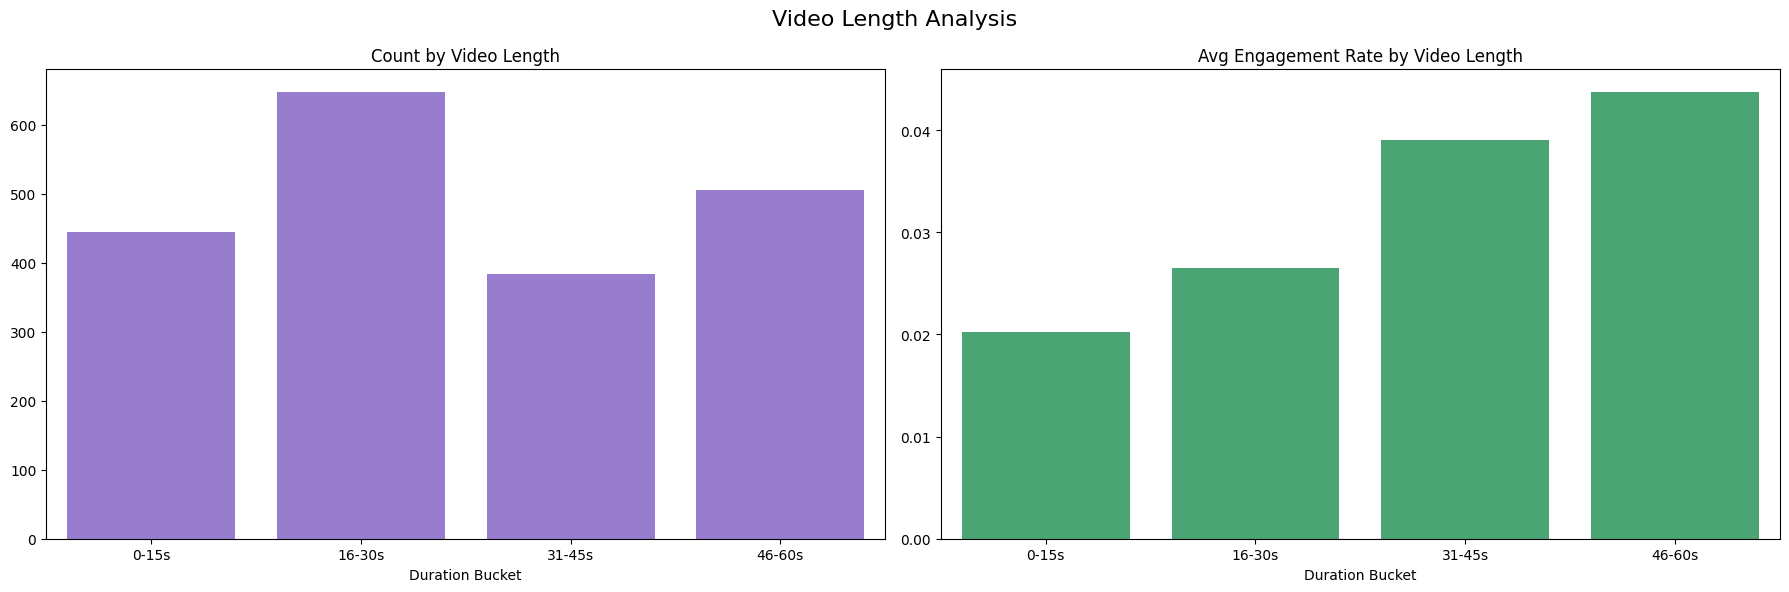

In [42]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# count per bucket
duration_counts = shorts_raw_df['duration_bucket'].value_counts().sort_index()
sns.barplot(x=duration_counts.index, y=duration_counts.values, ax=axes[0], color='mediumpurple')
axes[0].set_title('Count by Video Length')
axes[0].set_xlabel('Duration Bucket')

# avg engagement rate per bucket
avg_by_duration = shorts_raw_df.groupby('duration_bucket', observed=True)['engagement_rate'].mean()
sns.barplot(x=avg_by_duration.index, y=avg_by_duration.values, ax=axes[1], color='mediumseagreen')
axes[1].set_title('Avg Engagement Rate by Video Length')
axes[1].set_xlabel('Duration Bucket')

plt.suptitle('Video Length Analysis', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
print("Views stats:")
print(shorts_raw_df['views'].describe())
print(f"\nVideos over 1M views: {len(shorts_raw_df[shorts_raw_df['views'] > 1_000_000])}")
print(f"Videos over 10M views: {len(shorts_raw_df[shorts_raw_df['views'] > 10_000_000])}")
print(f"Videos with 0 views: {len(shorts_raw_df[shorts_raw_df['views'] == 0])}")

Views stats:
count    1.983000e+03
mean     5.594040e+06
std      1.901185e+07
min      1.500000e+01
25%      1.398850e+04
50%      4.277130e+05
75%      3.118497e+06
max      3.449089e+08
Name: views, dtype: float64

Videos over 1M views: 784
Videos over 10M views: 239
Videos with 0 views: 0


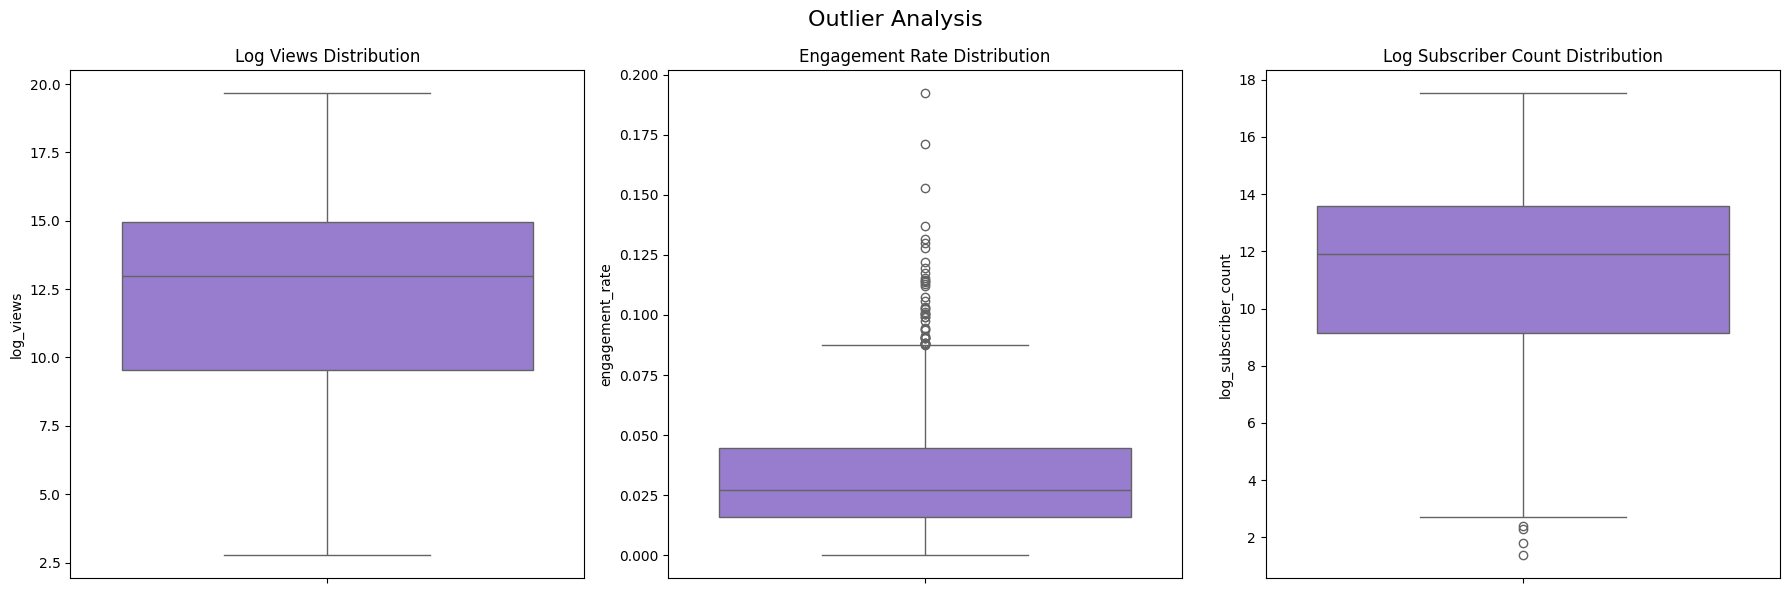

In [44]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

sns.boxplot(data=shorts_raw_df, y='log_views', ax=axes[0], color='mediumpurple')
axes[0].set_title('Log Views Distribution')

sns.boxplot(data=shorts_raw_df, y='engagement_rate', ax=axes[1], color='mediumpurple')
axes[1].set_title('Engagement Rate Distribution')

sns.boxplot(data=shorts_raw_df, y='log_subscriber_count', ax=axes[2], color='mediumpurple')
axes[2].set_title('Log Subscriber Count Distribution')

plt.suptitle('Outlier Analysis', fontsize=16)
plt.tight_layout()
plt.show()

In [45]:
# flag viral outliers using IQR method
Q1 = shorts_raw_df['views'].quantile(0.25)
Q3 = shorts_raw_df['views'].quantile(0.75)
IQR = Q3 - Q1

shorts_raw_df['is_viral'] = (shorts_raw_df['views'] > (Q3 + 1.5 * IQR)).astype(int)

print(f"Viral videos flagged: {shorts_raw_df['is_viral'].sum()}")
print(f"Non-viral videos: {(shorts_raw_df['is_viral'] == 0).sum()}")

Viral videos flagged: 289
Non-viral videos: 1694


In [75]:
print(f"Viral threshold: {Q3 + 1.5 * IQR:,.0f} views")
print(f"Q1: {Q1:,.0f} views")
print(f"Q3: {Q3:,.0f} views")
print(f"IQR: {IQR:,.0f}")
print(f"\nViral videos (>{Q3 + 1.5 * IQR:,.0f} views): {shorts_raw_df['is_viral'].sum()}")
print(f"Non-viral videos: {(shorts_raw_df['is_viral'] == 0).sum()}")
print(f"Viral rate: {shorts_raw_df['is_viral'].mean():.1%}")

Viral threshold: 7,775,260 views
Q1: 13,988 views
Q3: 3,118,497 views
IQR: 3,104,508

Viral videos (>7,775,260 views): 289
Non-viral videos: 1694
Viral rate: 14.6%


In [54]:
shorts_raw_df['log_comment_rate'] = np.log1p(shorts_raw_df['comment_rate'])
shorts_raw_df['log_view_velocity'] = np.log1p(shorts_raw_df['view_velocity'])

In [57]:
numerical_cols = ['duration_seconds', 'days_since_upload', 'hour',
                  'log_views', 'log_likes', 'log_comments',
                  'log_subscriber_count', 'log_total_channel_views', 'log_total_videos',
                  'engagement_rate', 'like_rate','log_view_velocity']

categorical_cols = ['subscriber_tier', 'duration_bucket',
                    'day_of_week', 'hour_bucket', 'month', 'quarter', 'year']

boolean_cols = ['is_viral']

In [47]:
import math

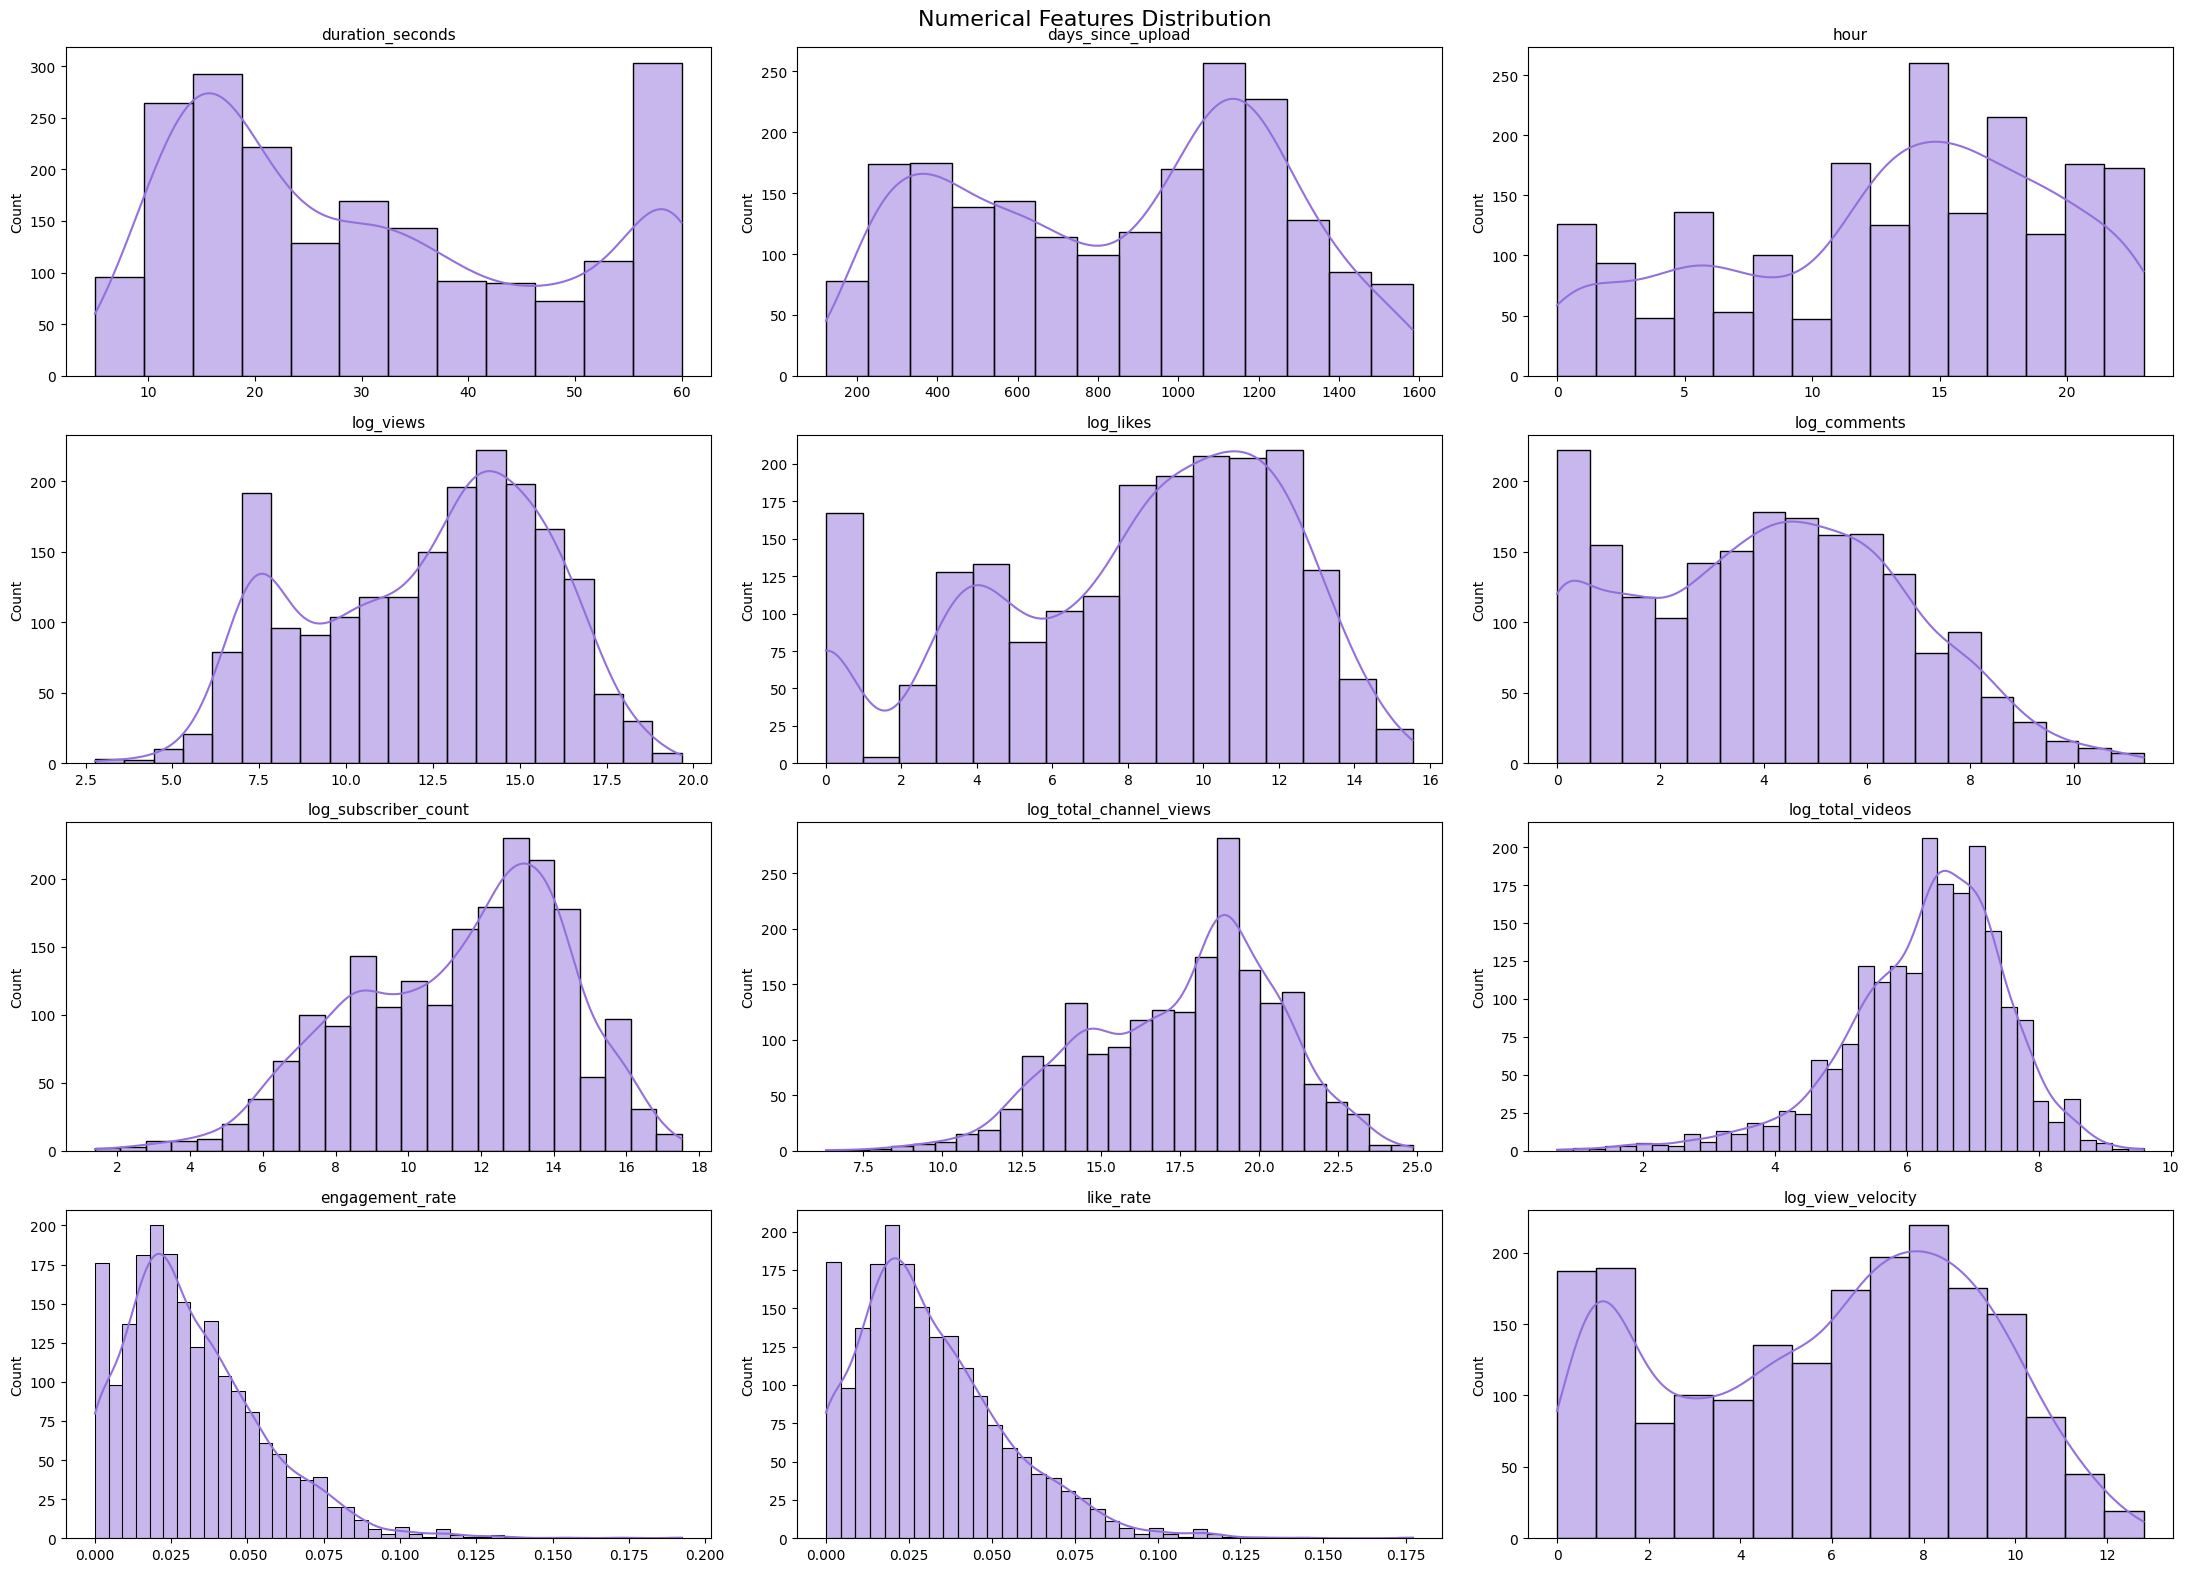

In [58]:
n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(22, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=shorts_raw_df, x=col, ax=axes[i], kde=True, color='mediumpurple')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features Distribution', fontsize=16)
plt.tight_layout()
plt.show()

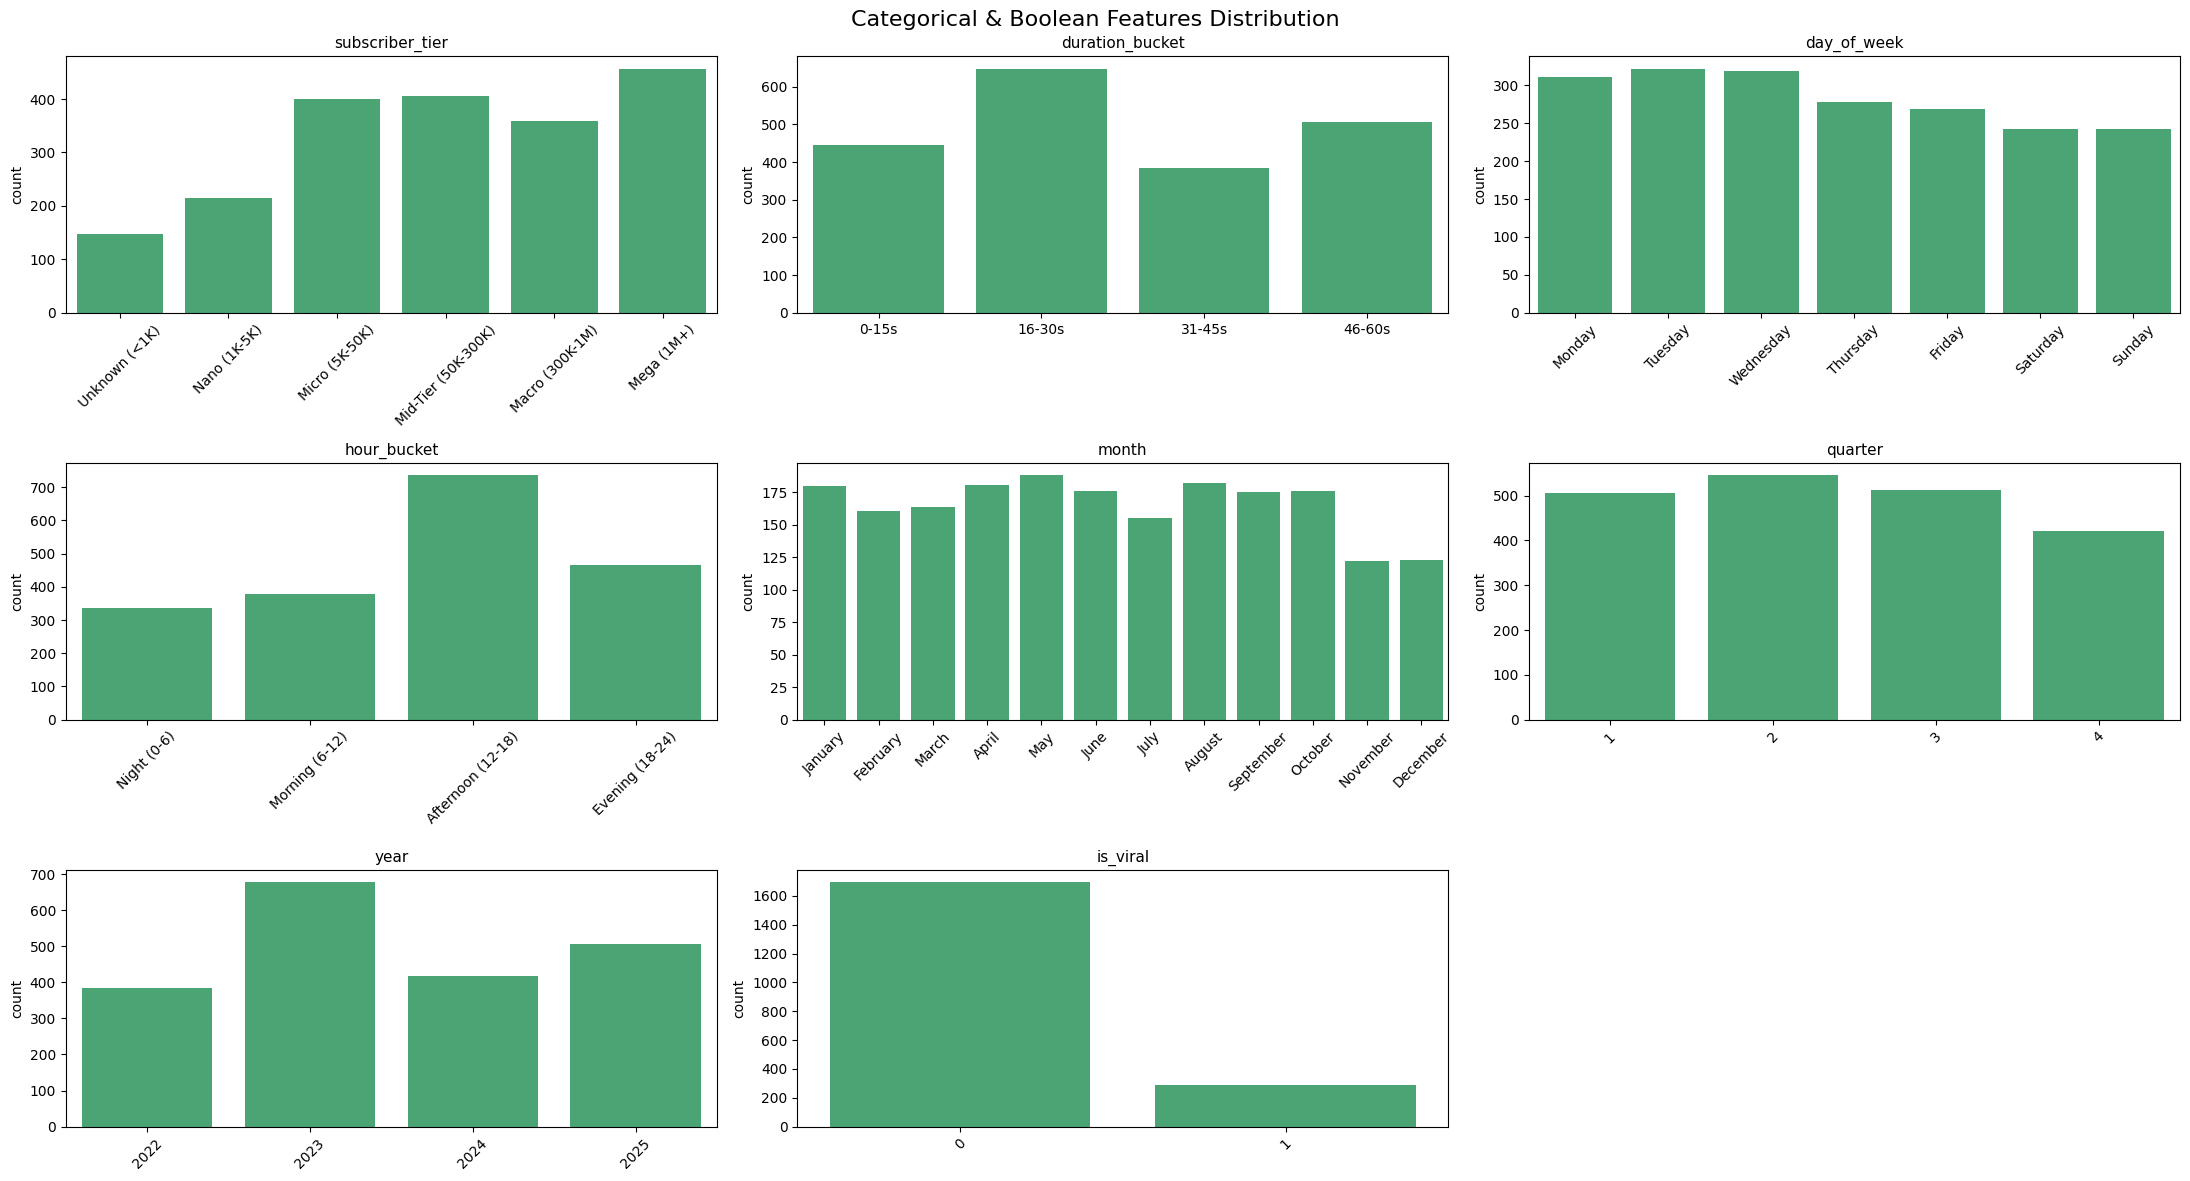

In [53]:
cat_bool_cols = categorical_cols + boolean_cols
n_rows = math.ceil(len(cat_bool_cols) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(22, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_bool_cols):
    ax = axes[i]

    if col == 'day_of_week':
        sns.countplot(data=shorts_raw_df, x=col, ax=ax, order=day_order, color='mediumseagreen')
        ax.tick_params(axis='x', rotation=45)
    elif col == 'month':
        sns.countplot(data=shorts_raw_df, x=col, ax=ax, order=month_order, color='mediumseagreen')
        ax.tick_params(axis='x', rotation=45)
    elif col == 'subscriber_tier':
        sns.countplot(data=shorts_raw_df, x=col, ax=ax, order=tier_order, color='mediumseagreen')
        ax.tick_params(axis='x', rotation=45)
    elif col == 'duration_bucket':
        sns.countplot(data=shorts_raw_df, x=col, ax=ax,
                      order=['0-15s', '16-30s', '31-45s', '46-60s'], color='mediumseagreen')
    elif col == 'hour_bucket':
        sns.countplot(data=shorts_raw_df, x=col, ax=ax,
                      order=['Night (0-6)', 'Morning (6-12)', 'Afternoon (12-18)', 'Evening (18-24)'],
                      color='mediumseagreen')
        ax.tick_params(axis='x', rotation=45)
    else:
        sns.countplot(data=shorts_raw_df, x=col, ax=ax, color='mediumseagreen')
        ax.tick_params(axis='x', rotation=45)

    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')

for j in range(len(cat_bool_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical & Boolean Features Distribution', fontsize=16)
plt.tight_layout()
plt.show()

In [59]:
shorts_clean_df = shorts_raw_df[[
    # identifiers
    'video_id',
    'channel_id',

    # numerical features
    'duration_seconds',
    'days_since_upload',
    'hour',
    'log_views',
    'log_likes',
    'log_comments',
    'log_subscriber_count',
    'log_total_channel_views',
    'log_total_videos',
    'log_view_velocity',
    'engagement_rate',
    'like_rate',

    # categorical features
    'content_type',
    'subscriber_tier',
    'duration_bucket',
    'day_of_week',
    'hour_bucket',
    'month',
    'quarter',
    'year',

    # boolean
    'is_viral',

]].copy()

print(shorts_clean_df.shape)
print(shorts_clean_df.dtypes)

(1983, 23)
video_id                        str
channel_id                      str
duration_seconds              int32
days_since_upload             int32
hour                          int32
log_views                   float64
log_likes                   float64
log_comments                float64
log_subscriber_count        float64
log_total_channel_views     float64
log_total_videos            float64
log_view_velocity           float32
engagement_rate             float32
like_rate                   float32
content_type                    str
subscriber_tier                 str
duration_bucket            category
day_of_week                     str
hour_bucket                category
month                           str
quarter                       int32
year                          int32
is_viral                      int64
dtype: object


In [61]:
cat_cols = ['content_type', 'subscriber_tier', 'day_of_week', 'month']
for col in cat_cols:
    shorts_clean_df[col] = shorts_clean_df[col].astype('category')

In [62]:
log_cols = ['log_views', 'log_likes', 'log_comments',
            'log_subscriber_count', 'log_total_channel_views', 'log_total_videos']
for col in log_cols:
    shorts_clean_df[col] = shorts_clean_df[col].astype('float32')

In [63]:
shorts_clean_df['is_viral'] = shorts_clean_df['is_viral'].astype('int8')

In [64]:
shorts_clean_df['quarter'] = shorts_clean_df['quarter'].astype('int16')
shorts_clean_df['year'] = shorts_clean_df['year'].astype('int16')

In [ ]:
print(shorts_clean_df.dtypes)
print(shorts_clean_df.memory_usage(deep=True).sum() / 1024, "KB")

In [ ]:
shorts_clean_df.head(10)

In [68]:
shorts_clean_df['published_at'] = shorts_raw_df['published_at']

In [ ]:
shorts_clean_df['published_at'] = pd.to_datetime(shorts_clean_df['published_at'])
print(shorts_clean_df['published_at'].dtype)

In [72]:
shorts_clean_df = shorts_clean_df[[
    # identifiers
    'video_id',
    'channel_id',

    # time features
    'published_at',
    'year',
    'quarter',
    'month',
    'day_of_week',
    'hour',
    'hour_bucket',
    'days_since_upload',

    # video features
    'duration_seconds',
    'duration_bucket',
    'content_type',

    # channel features
    'subscriber_tier',
    'log_subscriber_count',
    'log_total_channel_views',
    'log_total_videos',

    # engagement metrics
    'log_views',
    'log_likes',
    'log_comments',
    'log_view_velocity',
    'engagement_rate',
    'like_rate',
    'is_viral',
]]

print(shorts_clean_df.columns.tolist())

['video_id', 'channel_id', 'published_at', 'year', 'quarter', 'month', 'day_of_week', 'hour', 'hour_bucket', 'days_since_upload', 'duration_seconds', 'duration_bucket', 'content_type', 'subscriber_tier', 'log_subscriber_count', 'log_total_channel_views', 'log_total_videos', 'log_views', 'log_likes', 'log_comments', 'log_view_velocity', 'engagement_rate', 'like_rate', 'is_viral']


In [74]:
shorts_clean_df.head(10)

,video_id,channel_id,published_at,year,quarter,month,day_of_week,hour,hour_bucket,days_since_upload,...,log_subscriber_count,log_total_channel_views,log_total_videos,log_views,log_likes,log_comments,log_view_velocity,engagement_rate,like_rate,is_viral
0,3punW8R-OBQ,UC73sF-7Ihcs1HpnXEEXZ2ew,2022-06-18 01:41:08+00:00,2022,2,June,Saturday,1,Night (0-6),1416,...,16.213406,23.261486,8.370547,15.789052,12.501990,7.988204,8.533657,0.0378,0.0374,0
1,5RFG4hVEW0Q,UC3ocVSGRoapPsbG8QrFX5kA,2025-08-16 16:30:02+00:00,2025,3,August,Saturday,16,Afternoon (12-18),260,...,13.475835,21.126143,7.606884,14.031835,10.697769,5.093750,8.471358,0.0358,0.0356,0
2,hbstT1uZpQw,UCpwlclcyceJHtihaaysgsbg,2024-10-30 19:50:33+00:00,2024,4,October,Wednesday,19,Evening (18-24),550,...,11.589896,16.694826,6.261492,14.143022,10.056337,5.262690,7.833481,0.0169,0.0168,0
3,YejAxKQ3Dwg,UCdzHDmZaxystjVTwLQumPiw,2024-08-01 00:05:18+00:00,2024,3,August,Thursday,0,NaN,641,...,14.200773,20.787504,5.811141,16.456013,12.182921,7.439559,9.993032,0.0141,0.0139,1
4,gyDRYoz9yAw,UCUlFo1jlYURiV2_ldmeP2Ag,2024-09-24 02:08:45+00:00,2024,3,September,Tuesday,2,Night (0-6),587,...,14.173185,19.756277,6.018593,15.180473,0.000000,7.115582,8.805600,0.0003,0.0000,0
5,PDUe1Im0FiA,UCsl2X3lIQuyxcq4ZAnFCX_A,2024-06-12 22:33:51+00:00,2024,2,June,Wednesday,22,Evening (18-24),690,...,13.460264,19.911541,6.463029,15.974547,12.852125,7.716906,9.437938,0.0443,0.0441,1
6,48CWj2I3cf0,UC1-_q30UyLTE9-HYYYOXIsg,2022-08-07 21:02:33+00:00,2022,3,August,Sunday,21,Evening (18-24),1365,...,9.836332,14.392440,4.532599,14.197675,0.000000,5.880533,6.979704,0.0002,0.0000,0
7,ZHCbdaU-5tg,UCCs4Grm4piPPIadJuIGCUfw,2023-05-15 06:40:15+00:00,2023,2,May,Monday,6,Night (0-6),1084,...,13.077368,19.057205,5.846439,16.809031,13.272929,6.842683,9.820671,0.0292,0.0291,1
8,tHiuBDhAOkQ,UCdHmYOxlWC2Wwpx5X2N2Iiw,2022-01-09 13:15:16+00:00,2022,1,January,Sunday,13,Afternoon (12-18),1575,...,9.741028,16.523428,2.639057,16.504637,11.913096,6.448889,9.142735,0.0102,0.0101,1
9,1c54IK_A3Vs,UCktKGwRmBowKmtRpnQ_wRqg,2025-01-15 00:00:01+00:00,2025,1,January,Wednesday,0,NaN,474,...,9.136802,15.653732,5.552959,14.679669,10.918302,5.365976,8.518652,0.0233,0.0233,0


In [76]:
# check all nulls
print(shorts_clean_df.isnull().sum()[shorts_clean_df.isnull().sum() > 0])

hour_bucket    68
dtype: int64


In [77]:
shorts_clean_df['hour_bucket'] = pd.cut(
    shorts_clean_df['hour'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night (0-6)', 'Morning (6-12)', 'Afternoon (12-18)', 'Evening (18-24)'],
    include_lowest=True
)

# verify
print(shorts_clean_df['hour_bucket'].isnull().sum())
print(shorts_clean_df['hour_bucket'].value_counts())

0
hour_bucket
Afternoon (12-18)    735
Evening (18-24)      467
Night (0-6)          404
Morning (6-12)       377
Name: count, dtype: int64


In [78]:
shorts_clean_df.to_csv('data/makeup_shorts_clean.csv', index=False)
print("Saved!")

Saved!
